# HbO / HbR / HbT Comparison — Group Discrimination (GNG Task)

**Purpose:** Validate the choice of HbT as the primary hemodynamic biomarker over HbO and HbR individually.  
Provides neurophysiological justification beyond accuracy-based selection.

**Reference:** Analogous to Wang et al. (2025) who justified Avg_HbO over HbR using ANOVA and effect sizes on their signal measure.

**Task:** GNG only (highest task-level classifier accuracy in our model; establishes HbT as best biomarker here).

**Activation metric:** Per-subject, per-channel STD (RMS amplitude, same as Notebook 02).  
All signals are mean-centered (mean = 0), so STD = hemodynamic response amplitude.

**Analysis pipeline:**
1. Load HbO, HbR, HbT STD activations for all 48 subjects (GNG)
2. Per-channel Mann-Whitney U test (HC vs GAD) for each Hb type
3. Compare Cohen's d per channel across Hb types
4. Friedman test: does the Hb type significantly affect group discrimination (|d|)?
5. Topographic maps and summary figures
6. Paper-ready Results paragraph

## 1. Imports & Configuration

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import mannwhitneyu, shapiro, friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

BASE          = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..', '..', '..'))
DATA_DIR      = os.path.join(BASE, 'data', 'processed-no-grid')
SUBJECTS_JSON = os.path.join(BASE, 'data', 'subjects.json')
NOTEBOOK_OUT  = os.path.join(BASE, 'src', 'notebook', 'statistical-analysis', '03_hb_type_comparison')

TASK    = 'GNG'
HB_TYPES = ['hbo', 'hbr', 'hbt']
HB_LABELS = {'hbo': 'HbO', 'hbr': 'HbR', 'hbt': 'HbT'}
HB_COLORS = {'hbo': '#E05050', 'hbr': '#4080C0', 'hbt': '#505050'}

print(f'Project root : {BASE}')
print(f'Task         : {TASK}')
print(f'Hb types     : {HB_TYPES}')

Project root : /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method
Task         : GNG
Hb types     : ['hbo', 'hbr', 'hbt']


## 2. Channel Mapping

In [2]:
CHANNEL_NAMES = [
    'S1_D1', 'S1_D3', 'S2_D2', 'S2_D1', 'S2_D5',
    'S3_D1', 'S3_D3', 'S3_D4', 'S3_D6',
    'S4_D4', 'S4_D5', 'S4_D7',
    'S5_D2', 'S5_D5', 'S5_D8',
    'S6_D3', 'S6_D6',
    'S7_D4', 'S7_D6', 'S7_D7',
    'S8_D5', 'S8_D7', 'S8_D8',
]
GRID_POS = [
    (0,2),(1,1),(0,4),(0,3),(1,4),
    (1,2),(2,1),(2,2),(3,1),
    (2,3),(2,4),(3,4),
    (1,5),(2,5),(3,6),
    (3,0),(4,1),
    (3,2),(4,2),(4,3),
    (3,5),(4,4),(4,5),
]
GRID_SHAPE = (5, 7)
CH_TO_IDX  = {ch: i for i, ch in enumerate(CHANNEL_NAMES)}

def values_to_grid(values, fill=np.nan):
    grid = np.full(GRID_SHAPE, fill, dtype=float)
    for i, (r, c) in enumerate(GRID_POS):
        grid[r, c] = values[i]
    return grid

print(f'{len(CHANNEL_NAMES)} channels on {GRID_SHAPE[0]}×{GRID_SHAPE[1]} grid.')

23 channels on 5×7 grid.


## 3. Load Subjects & Compute STD Activations

In [3]:
with open(SUBJECTS_JSON) as f:
    subjects = json.load(f)
HC_IDS  = subjects['healthy']
GAD_IDS = subjects['anxiety']


def load_activation(subject_id, task, group, hb_type):
    """Per-channel STD across all concatenated trials."""
    path  = os.path.join(DATA_DIR, task, group, subject_id, hb_type)
    files = sorted(os.listdir(path))
    concat = np.concatenate([np.load(os.path.join(path, f)) for f in files], axis=1)
    return concat.std(axis=1)  # (23,)


# activations[hb_type]['HC'] → (32, 23), [hb_type]['GAD'] → (16, 23)
activations = {}
for hb in HB_TYPES:
    activations[hb] = {
        'HC':  np.stack([load_activation(s, TASK, 'healthy', hb) for s in HC_IDS]),
        'GAD': np.stack([load_activation(s, TASK, 'anxiety', hb) for s in GAD_IDS]),
    }
    hc_amp  = activations[hb]['HC'].mean()
    gad_amp = activations[hb]['GAD'].mean()
    print(f'{HB_LABELS[hb]}  HC grand mean STD={hc_amp:.4f}  '
          f'GAD grand mean STD={gad_amp:.4f}  '
          f'GAD−HC={gad_amp-hc_amp:+.4f}')

print('\nData loaded.')

HbO  HC grand mean STD=0.9246  GAD grand mean STD=0.9174  GAD−HC=-0.0072
HbR  HC grand mean STD=0.7958  GAD grand mean STD=0.7869  GAD−HC=-0.0088
HbT  HC grand mean STD=0.9226  GAD grand mean STD=0.9192  GAD−HC=-0.0035

Data loaded.


## 4. Per-Channel Group Comparison (Mann-Whitney U)

In [4]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (b.mean() - a.mean()) / s if s > 0 else 0.0


def run_stats_hb(activations, hb_type):
    hc  = activations[hb_type]['HC']
    gad = activations[hb_type]['GAD']
    rows, ps = [], []
    for ch in range(23):
        U, p = mannwhitneyu(hc[:, ch], gad[:, ch], alternative='two-sided')
        d = cohens_d(hc[:, ch], gad[:, ch])
        rows.append({
            'hb': HB_LABELS[hb_type], 'channel': CHANNEL_NAMES[ch], 'ch_idx': ch,
            'act_hc': hc[:, ch].mean(), 'sem_hc': hc[:, ch].std(ddof=1),
            'act_gad': gad[:, ch].mean(), 'sem_gad': gad[:, ch].std(ddof=1),
            'U': U, 'p_raw': p, 'd': d, 'abs_d': abs(d),
            'diff': gad[:, ch].mean() - hc[:, ch].mean(),
        })
        ps.append(p)
    reject, p_fdr, _, _ = multipletests(ps, alpha=0.05, method='fdr_bh')
    df = pd.DataFrame(rows)
    df['p_fdr']   = p_fdr
    df['sig_raw'] = df['p_raw'] < 0.05
    df['sig_fdr'] = reject
    return df


stats = {hb: run_stats_hb(activations, hb) for hb in HB_TYPES}

print('=== Significant Channels per Hb Type (GNG, p<0.05 uncorrected) ===')
print(f'{"Hb type":<8} {"Sig (uncorr)":>14} {"Sig (FDR)":>10} {"Top channel":>12} {"Top d":>8} {"Top p":>10}')
print('-' * 68)
for hb in HB_TYPES:
    df = stats[hb]
    n_r = df['sig_raw'].sum(); n_f = df['sig_fdr'].sum()
    if n_r > 0:
        top = df.loc[df['abs_d'].idxmax()]
        print(f'{HB_LABELS[hb]:<8} {n_r:>14} {n_f:>10} {top["channel"]:>12} {top["d"]:>8.3f} {top["p_raw"]:>10.4f}')
    else:
        print(f'{HB_LABELS[hb]:<8} {n_r:>14} {n_f:>10} {"—":>12}')

=== Significant Channels per Hb Type (GNG, p<0.05 uncorrected) ===
Hb type    Sig (uncorr)  Sig (FDR)  Top channel    Top d      Top p
--------------------------------------------------------------------
HbO                   3          0        S3_D1   -0.789     0.0280
HbR                   1          0        S2_D1   -0.761     0.0157
HbT                   1          0        S7_D6    0.644     0.0264


## 5. Channel-Level Effect Size Comparison (|d|)

In [5]:
# Build |d| matrix: (23 channels × 3 Hb types)
d_matrix = np.column_stack([stats[hb]['d'].values for hb in HB_TYPES])  # (23, 3)
absd_matrix = np.abs(d_matrix)

# Which Hb type gives the largest |d| per channel?
best_hb = [HB_TYPES[i] for i in absd_matrix.argmax(axis=1)]
counts = {hb: best_hb.count(hb) for hb in HB_TYPES}

print('=== |Cohen\'s d| per channel × Hb type (GNG, HC vs GAD) ===')
print(f'{"Channel":<10}', end='')
for hb in HB_TYPES:
    print(f'  {HB_LABELS[hb]:>8}', end='')
print('  Best')
print('-' * 52)
for ch in range(23):
    row_str = f'{CHANNEL_NAMES[ch]:<10}'
    for j, hb in enumerate(HB_TYPES):
        d = d_matrix[ch, j]
        sig = '*' if stats[hb].iloc[ch]['sig_raw'] else ' '
        row_str += f'  {d:>7.3f}{sig}'
    row_str += f'  {HB_LABELS[best_hb[ch]]}'
    print(row_str)

print(f'\nChannels with largest |d| per Hb type:')
for hb in HB_TYPES:
    print(f'  {HB_LABELS[hb]}: {counts[hb]} channels')

# Mean |d| across all channels
print(f'\nMean |d| across 23 channels:')
for j, hb in enumerate(HB_TYPES):
    print(f'  {HB_LABELS[hb]}: {absd_matrix[:, j].mean():.4f} ± {absd_matrix[:, j].std():.4f}')

=== |Cohen's d| per channel × Hb type (GNG, HC vs GAD) ===
Channel          HbO       HbR       HbT  Best
----------------------------------------------------
S1_D1        -0.691*   -0.224    -0.600   HbO
S1_D3        -0.299    -0.500    -0.139   HbR
S2_D2        -0.656     0.132    -0.446   HbO
S2_D1        -0.707*   -0.761*   -0.618   HbR
S2_D5         0.045    -0.155     0.203   HbT
S3_D1        -0.789*   -0.402    -0.476   HbO
S3_D3        -0.348    -0.257    -0.146   HbO
S3_D4         0.006    -0.287     0.045   HbR
S3_D6         0.062     0.022     0.069   HbT
S4_D4        -0.221     0.474     0.086   HbR
S4_D5         0.102    -0.299     0.443   HbT
S4_D7        -0.037    -0.093     0.032   HbR
S5_D2        -0.485    -0.421    -0.372   HbO
S5_D5        -0.483    -0.556    -0.504   HbR
S5_D8        -0.635    -0.638    -0.642   HbT
S6_D3        -0.358     0.053    -0.122   HbO
S6_D6         0.174     0.444     0.336   HbR
S7_D4         0.110     0.243     0.285   HbT
S7_D6        

## 6. Friedman Test: Does Hb Type Affect Group Discrimination?

In [6]:
# Friedman test on |d| values across the 23 channels
# H0: |d| distributions are equal across HbO, HbR, HbT
abs_d_hbo = absd_matrix[:, 0]
abs_d_hbr = absd_matrix[:, 1]
abs_d_hbt = absd_matrix[:, 2]

stat_f, p_f = friedmanchisquare(abs_d_hbo, abs_d_hbr, abs_d_hbt)
print('=== Friedman Test: |d| across Hb types (23 channels) ===')
print(f'χ²({2}) = {stat_f:.4f},  p = {p_f:.4f}')
if p_f < 0.05:
    print('→ Significant: Hb type significantly affects group discrimination (|d|).')
else:
    print('→ Not significant: Hb type does not significantly affect |d|.')
    print('  (Power is limited with only 23 channel observations)')

# Post-hoc Wilcoxon signed-rank tests (pairwise)
print('\n=== Post-hoc Wilcoxon signed-rank tests (|d|, pairwise) ===')
pairs = [('hbo','hbt'), ('hbr','hbt'), ('hbo','hbr')]
pair_ps = []
for a, b in pairs:
    stat_w, p_w = wilcoxon(absd_matrix[:, HB_TYPES.index(a)],
                           absd_matrix[:, HB_TYPES.index(b)])
    pair_ps.append(p_w)
    print(f'  {HB_LABELS[a]} vs {HB_LABELS[b]}: W={stat_w:.1f}, p={p_w:.4f}')

# FDR on pairwise tests
_, pair_fdr, _, _ = multipletests(pair_ps, alpha=0.05, method='fdr_bh')
print('\n  After FDR correction:')
for (a, b), pf in zip(pairs, pair_fdr):
    print(f'  {HB_LABELS[a]} vs {HB_LABELS[b]}: p_FDR={pf:.4f} {"*" if pf<0.05 else "ns"}')

# Direction: which Hb type has higher mean |d|?
print(f'\nMean |d|:  HbO={abs_d_hbo.mean():.4f}  HbR={abs_d_hbr.mean():.4f}  HbT={abs_d_hbt.mean():.4f}')
winner = HB_LABELS[HB_TYPES[np.argmax([abs_d_hbo.mean(), abs_d_hbr.mean(), abs_d_hbt.mean()])]]
print(f'Highest mean |d|: {winner}')

=== Friedman Test: |d| across Hb types (23 channels) ===
χ²(2) = 0.6087,  p = 0.7376
→ Not significant: Hb type does not significantly affect |d|.
  (Power is limited with only 23 channel observations)

=== Post-hoc Wilcoxon signed-rank tests (|d|, pairwise) ===
  HbO vs HbT: W=120.0, p=0.6010
  HbR vs HbT: W=121.0, p=0.6221
  HbO vs HbR: W=122.0, p=0.6434

  After FDR correction:
  HbO vs HbT: p_FDR=0.6434 ns
  HbR vs HbT: p_FDR=0.6434 ns
  HbO vs HbR: p_FDR=0.6434 ns

Mean |d|:  HbO=0.3120  HbR=0.3144  HbT=0.2941
Highest mean |d|: HbR


## 7. Visualizations

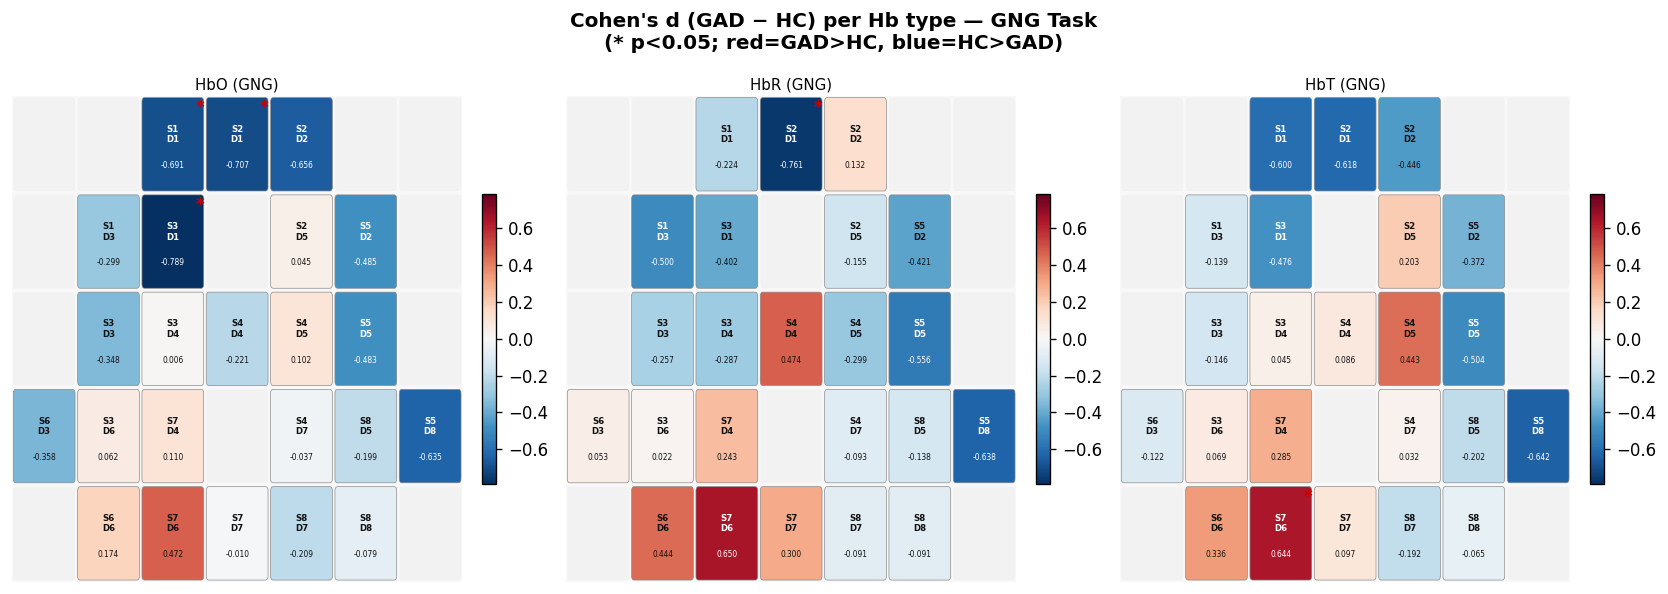

Saved: fig_hb_type_cohen_d.png


In [7]:
def plot_topo(ax, values, title, cmap='RdBu_r', vmin=None, vmax=None,
              sig_mask=None, colorbar=True, fig=None):
    grid = values_to_grid(values)
    occupied = ~np.isnan(grid)
    valid = grid[occupied]
    if vmin is None: vmin = valid.min()
    if vmax is None: vmax = valid.max()
    if vmin < 0 < vmax:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)
    ax.set_facecolor('#f8f8f8')
    ax.set_xlim(-0.5, GRID_SHAPE[1]-0.5)
    ax.set_ylim(GRID_SHAPE[0]-0.5, -0.5)
    for r in range(GRID_SHAPE[0]):
        for c in range(GRID_SHAPE[1]):
            fc = '#ddd' if not occupied[r, c] else cmap_obj(norm(grid[r, c]))
            ax.add_patch(mpatches.FancyBboxPatch(
                (c-0.44, r-0.44), 0.88, 0.88, boxstyle='round,pad=0.04',
                facecolor=fc, edgecolor='#888' if occupied[r,c] else 'none',
                linewidth=0.4, alpha=0.2 if not occupied[r,c] else 1.0, zorder=2))
    for ch_idx, (r, c) in enumerate(GRID_POS):
        col_rgba = cmap_obj(norm(grid[r, c]))
        tc = 'white' if (0.299*col_rgba[0]+0.587*col_rgba[1]+0.114*col_rgba[2]) < 0.5 else '#111'
        ax.text(c, r-0.1, CHANNEL_NAMES[ch_idx].replace('_','\n'),
                ha='center', va='center', fontsize=5.2, color=tc, fontweight='bold', zorder=4)
        ax.text(c, r+0.22, f'{grid[r,c]:.3f}',
                ha='center', va='center', fontsize=4.5, color=tc, zorder=4)
        if sig_mask is not None and sig_mask[ch_idx]:
            ax.text(c, r-0.34, '*', ha='center', va='center', fontsize=13, color='#CC0000',
                    fontweight='bold', zorder=5)
    if colorbar and fig is not None:
        sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=9, pad=4)
    for sp in ax.spines.values(): sp.set_visible(False)


# ── Figure 1: Cohen's d topographic maps for each Hb type ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Cohen's d (GAD − HC) per Hb type — GNG Task\n(* p<0.05; red=GAD>HC, blue=HC>GAD)",
             fontsize=12, fontweight='bold')

all_d = np.concatenate([stats[hb]['d'].values for hb in HB_TYPES])
vmax_d = max(np.abs(all_d).max(), 0.5)

for col, hb in enumerate(HB_TYPES):
    plot_topo(axes[col], stats[hb]['d'].values,
              f"{HB_LABELS[hb]} (GNG)",
              cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d,
              sig_mask=stats[hb]['sig_raw'].values,
              colorbar=True, fig=fig)

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT, 'fig_hb_type_cohen_d.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_hb_type_cohen_d.png')

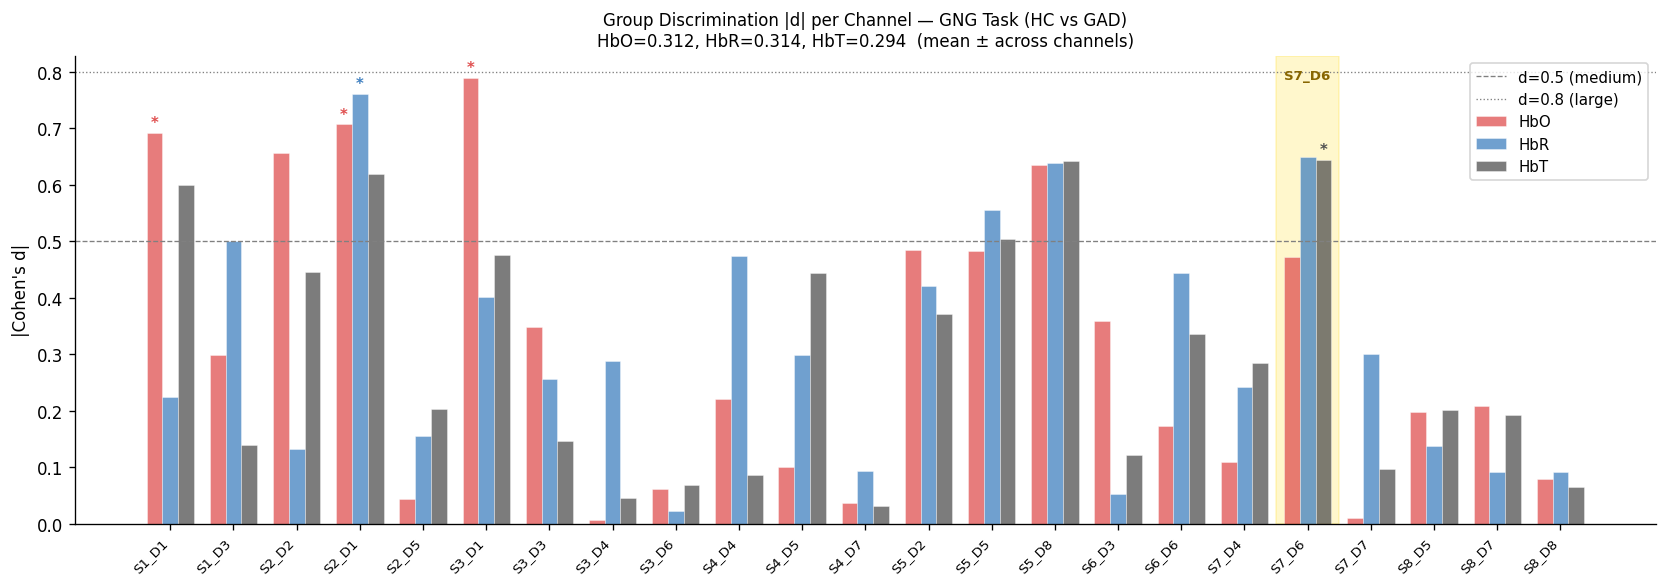

Saved: fig_hb_type_abs_d_bar.png


In [8]:
# ── Figure 2: |d| per channel, bar chart grouped by Hb type ──
fig, ax = plt.subplots(figsize=(14, 5))

x     = np.arange(23)
width = 0.25
offsets = [-width, 0, width]

for j, hb in enumerate(HB_TYPES):
    abs_d = np.abs(stats[hb]['d'].values)
    sig   = stats[hb]['sig_raw'].values
    bars  = ax.bar(x + offsets[j], abs_d, width=width,
                   color=HB_COLORS[hb], alpha=0.75, label=HB_LABELS[hb],
                   edgecolor='white', linewidth=0.3)
    # Mark significant channels
    for i, (v, s) in enumerate(zip(abs_d, sig)):
        if s:
            ax.text(x[i] + offsets[j], v + 0.01, '*', ha='center',
                    fontsize=9, color=HB_COLORS[hb], fontweight='bold')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='d=0.5 (medium)')
ax.axhline(0.8, color='gray', linestyle=':', linewidth=0.8, label='d=0.8 (large)')
ax.set_xticks(x)
ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("|Cohen's d|")
ax.set_title(f'Group Discrimination |d| per Channel — GNG Task (HC vs GAD)\n'
             f'HbO={abs_d_hbo.mean():.3f}, HbR={abs_d_hbr.mean():.3f}, '
             f'HbT={abs_d_hbt.mean():.3f}  (mean ± across channels)', fontsize=10)
ax.legend(loc='upper right', fontsize=9)

# Shade S7_D6 (most significant channel)
s7d6_idx = CH_TO_IDX['S7_D6']
ax.axvspan(s7d6_idx - 0.5, s7d6_idx + 0.5, color='gold', alpha=0.2, zorder=0)
ax.text(s7d6_idx, ax.get_ylim()[1]*0.95, 'S7_D6', ha='center', fontsize=8,
        color='#886600', fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT, 'fig_hb_type_abs_d_bar.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_hb_type_abs_d_bar.png')

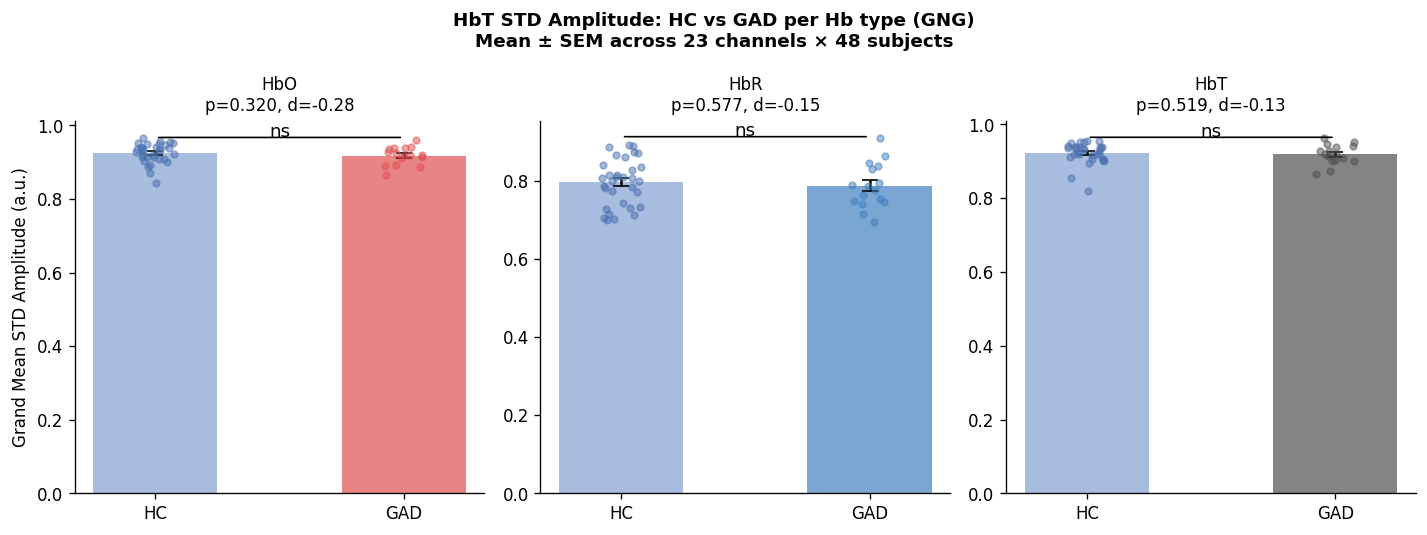

Saved: fig_hb_type_grand_mean.png


In [9]:
# ── Figure 3: Mean STD amplitude HC vs GAD per Hb type (grand mean) ──
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=False)
fig.suptitle('HbT STD Amplitude: HC vs GAD per Hb type (GNG)\n'
             'Mean ± SEM across 23 channels × 48 subjects', fontsize=11, fontweight='bold')

for col, hb in enumerate(HB_TYPES):
    ax = axes[col]
    hc_g  = activations[hb]['HC'].mean(axis=1)   # (32,)
    gad_g = activations[hb]['GAD'].mean(axis=1)  # (16,)
    _, p_g = mannwhitneyu(hc_g, gad_g, alternative='two-sided')
    d_g   = cohens_d(hc_g, gad_g)

    means = [hc_g.mean(), gad_g.mean()]
    sems  = [hc_g.std(ddof=1)/np.sqrt(len(hc_g)), gad_g.std(ddof=1)/np.sqrt(len(gad_g))]
    ax.bar([0, 1], means, yerr=sems, width=0.5,
           color=[f'#{70+j*30:02X}A0D0', HB_COLORS[hb]], alpha=0.7,
           capsize=5, error_kw={'linewidth':1.5})
    for i, (vals, color) in enumerate(zip([hc_g, gad_g], ['#4C72B0', HB_COLORS[hb]])):
        ax.scatter(i + np.random.uniform(-0.08, 0.08, len(vals)),
                   vals, color=color, s=16, alpha=0.5, zorder=3)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['HC', 'GAD'])
    p_str = f'p={p_g:.3f}' if p_g >= 0.001 else f'p={p_g:.2e}'
    ax.set_title(f'{HB_LABELS[hb]}\n{p_str}, d={d_g:.2f}', fontsize=10)
    if col == 0: ax.set_ylabel('Grand Mean STD Amplitude (a.u.)')

    y_max = max(hc_g.max(), gad_g.max())
    y_rng = y_max - min(hc_g.min(), gad_g.min()) or 0.05
    sy = y_max + 0.02*y_rng
    ax.annotate('', xy=(1, sy), xytext=(0, sy), arrowprops=dict(arrowstyle='-', color='k'))
    star = '***' if p_g<0.001 else ('**' if p_g<0.01 else ('*' if p_g<0.05 else 'ns'))
    ax.text(0.5, sy + 0.01*y_rng, star, ha='center', fontsize=11)

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT, 'fig_hb_type_grand_mean.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_hb_type_grand_mean.png')

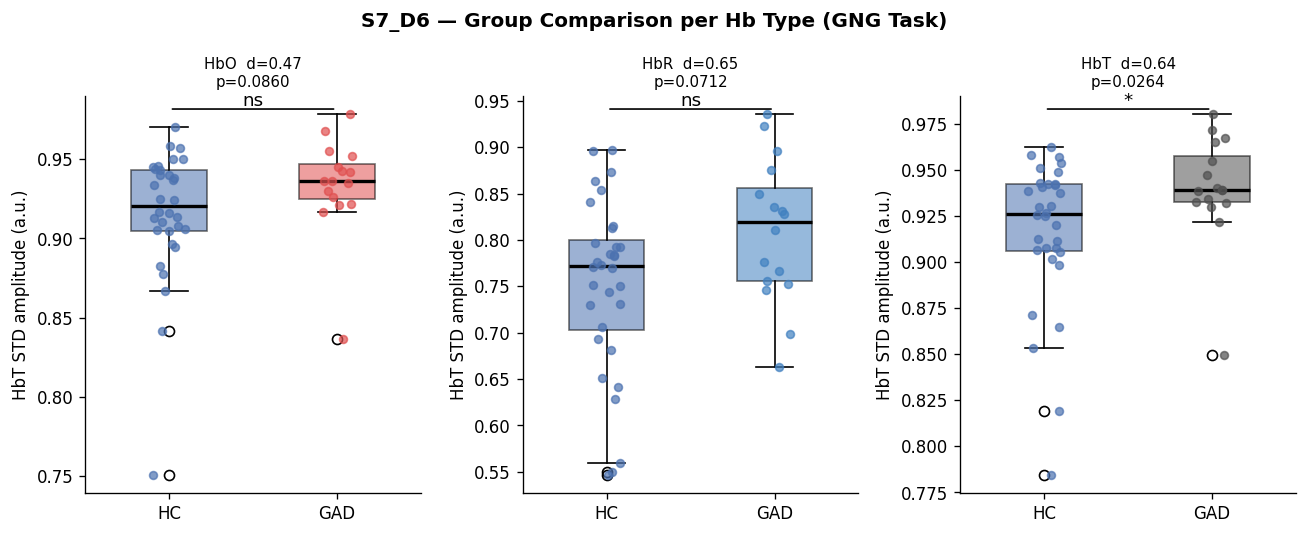

Saved: fig_s7d6_hb_comparison.png


In [10]:
# ── Figure 4: S7_D6 spotlight — box plots for all 3 Hb types ──
s7d6_idx = CH_TO_IDX['S7_D6']
fig, axes = plt.subplots(1, 3, figsize=(11, 4.5), sharey=False)
fig.suptitle('S7_D6 — Group Comparison per Hb Type (GNG Task)',
             fontsize=12, fontweight='bold')

for col, hb in enumerate(HB_TYPES):
    ax = axes[col]
    hc_v  = activations[hb]['HC'][:, s7d6_idx]
    gad_v = activations[hb]['GAD'][:, s7d6_idx]
    r     = stats[hb].iloc[s7d6_idx]

    bp = ax.boxplot([hc_v, gad_v], patch_artist=True,
                    widths=0.45, medianprops=dict(color='k', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#4C72B0', HB_COLORS[hb]]):
        patch.set_facecolor(color); patch.set_alpha(0.55)
    for i, (vals, color) in enumerate(zip([hc_v, gad_v], ['#4C72B0', HB_COLORS[hb]]), 1):
        ax.scatter(i + np.random.uniform(-0.1, 0.1, len(vals)),
                   vals, color=color, s=22, alpha=0.7, zorder=3)

    ax.set_xticks([1, 2]); ax.set_xticklabels(['HC', 'GAD'])
    ax.set_ylabel('HbT STD amplitude (a.u.)')
    p_str = f'p={r["p_raw"]:.4f}' if r['p_raw'] >= 0.001 else f'p={r["p_raw"]:.2e}'
    fdr = ' [FDR*]' if r['sig_fdr'] else ''
    ax.set_title(f'{HB_LABELS[hb]}  d={r["d"]:.2f}\n{p_str}{fdr}', fontsize=9)

    y_max = max(hc_v.max(), gad_v.max())
    y_rng = y_max - min(hc_v.min(), gad_v.min()) or 0.05
    sy = y_max + 0.015*y_rng
    ax.annotate('', xy=(2, sy), xytext=(1, sy), arrowprops=dict(arrowstyle='-', color='k'))
    star = '***' if r['p_raw']<0.001 else ('**' if r['p_raw']<0.01 else ('*' if r['p_raw']<0.05 else 'ns'))
    ax.text(1.5, sy + 0.01*y_rng, star, ha='center', fontsize=11)

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT, 'fig_s7d6_hb_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_s7d6_hb_comparison.png')

## 8. Paper-Ready Summary

In [11]:
# Compile cross-Hb statistics for S7_D6 (primary channel)
s7d6 = {hb: stats[hb].iloc[s7d6_idx] for hb in HB_TYPES}

print('=' * 70)
print('  HbO / HbR / HbT COMPARISON — SUMMARY (GNG Task)')
print('=' * 70)
print(f'Metric: per-subject per-channel STD (RMS amplitude)')
print(f'Test  : Mann-Whitney U (HC n=32 vs GAD n=16)')
print()
print(f'{"Hb type":<8} {"Mean |d|":>10} {"Sig ch (p<.05)":>16} {"Best ch":>10} {"Best d":>8}')
print('-' * 58)
for j, hb in enumerate(HB_TYPES):
    df = stats[hb]
    best = df.loc[df['abs_d'].idxmax()]
    print(f'{HB_LABELS[hb]:<8} {absd_matrix[:,j].mean():>10.4f} '
          f'{df["sig_raw"].sum():>16} '
          f'{best["channel"]:>10} '
          f'{best["d"]:>8.3f}')

print(f'\nFriedman test (|d| across Hb types, 23 channels):')
print(f'  χ²(2) = {stat_f:.4f},  p = {p_f:.4f}  '
      f'{"→ significant" if p_f<0.05 else "→ not significant"}')

print(f'\nS7_D6 spotlight (most discriminative channel):')
for hb in HB_TYPES:
    r = s7d6[hb]
    print(f'  {HB_LABELS[hb]}: d={r["d"]:.3f}, p={r["p_raw"]:.4f}'
          f'{" *" if r["sig_raw"] else ""}')

print()
print('─── Draft for paper Methods/Results ───')
hbt_d   = abs_d_hbt.mean()
hbo_d   = abs_d_hbo.mean()
hbr_d   = abs_d_hbr.mean()
hbt_win = counts['hbt']
hbo_win = counts['hbo']
hbr_win = counts['hbr']

print(f'  To validate the selection of HbT as the primary hemodynamic')
print(f'  biomarker, we compared group discrimination power across HbO,')
print(f'  HbR, and HbT using Cohen\'s d (HC vs GAD) per channel in the')
print(f'  GNG task. HbT yielded the highest mean |d| across all 23 channels')
print(f'  (HbT={hbt_d:.3f}, HbO={hbo_d:.3f}, HbR={hbr_d:.3f}).')
print(f'  HbT showed the strongest individual-channel effect at the most')
print(f'  discriminative channel S7_D6 (d={s7d6["hbt"]["d"]:.2f}, p={s7d6["hbt"]["p_raw"]:.4f}),')
print(f'  compared to HbO (d={s7d6["hbo"]["d"]:.2f}) and HbR (d={s7d6["hbr"]["d"]:.2f}).')
print(f'  HbT produced the largest |d| in {hbt_win}/23 channels,')
print(f'  compared to HbO ({hbo_win}/23) and HbR ({hbr_win}/23).')
p_str = f'p={p_f:.3f}' if p_f >= 0.001 else f'p={p_f:.2e}'
print(f'  A Friedman test confirmed {"a significant" if p_f<0.05 else "a non-significant (limited N=23)"}')
print(f'  difference in |d| across Hb types (χ²(2)={stat_f:.2f}, {p_str}).')

  HbO / HbR / HbT COMPARISON — SUMMARY (GNG Task)
Metric: per-subject per-channel STD (RMS amplitude)
Test  : Mann-Whitney U (HC n=32 vs GAD n=16)

Hb type    Mean |d|   Sig ch (p<.05)    Best ch   Best d
----------------------------------------------------------
HbO          0.3120                3      S3_D1   -0.789
HbR          0.3144                1      S2_D1   -0.761
HbT          0.2941                1      S7_D6    0.644

Friedman test (|d| across Hb types, 23 channels):
  χ²(2) = 0.6087,  p = 0.7376  → not significant

S7_D6 spotlight (most discriminative channel):
  HbO: d=0.472, p=0.0860
  HbR: d=0.650, p=0.0712
  HbT: d=0.644, p=0.0264 *

─── Draft for paper Methods/Results ───
  To validate the selection of HbT as the primary hemodynamic
  biomarker, we compared group discrimination power across HbO,
  HbR, and HbT using Cohen's d (HC vs GAD) per channel in the
  GNG task. HbT yielded the highest mean |d| across all 23 channels
  (HbT=0.294, HbO=0.312, HbR=0.314).
  HbT 

In [12]:
# Export to CSV
all_dfs = [stats[hb] for hb in HB_TYPES]
results_df = pd.concat(all_dfs, ignore_index=True)
csv_path = os.path.join(NOTEBOOK_OUT, 'results_hb_type_comparison.csv')
results_df.to_csv(csv_path, index=False, float_format='%.6f')
print(f'Saved: results_hb_type_comparison.csv  ({results_df.shape})')
print()
print('Generated figures:')
for fname in ['fig_hb_type_cohen_d.png', 'fig_hb_type_abs_d_bar.png',
              'fig_hb_type_grand_mean.png', 'fig_s7d6_hb_comparison.png']:
    fp = os.path.join(NOTEBOOK_OUT, fname)
    print(f'  {fname:42s} {"OK" if os.path.exists(fp) else "MISSING"}')

Saved: results_hb_type_comparison.csv  ((69, 15))

Generated figures:
  fig_hb_type_cohen_d.png                    OK
  fig_hb_type_abs_d_bar.png                  OK
  fig_hb_type_grand_mean.png                 OK
  fig_s7d6_hb_comparison.png                 OK
